# Trader Behavior vs Fear & Greed Sentiment

This notebook analyzes whether trader performance and behavior differ between **Fear** and **Greed** market sentiment days.

## Files
- `historical_data.csv`
- `fear_greed_index.csv`

## Main questions
1. Does performance differ between Fear vs Greed days?
2. Do traders change behavior based on sentiment?
3. Which trader segments behave differently?
4. What strategy rules of thumb can we recommend?


## 1) Load data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSVs into DataFrames
fear = pd.read_csv('/content/fear_greed_index.csv')
hist = pd.read_csv('/content/historical_data.csv')

# Check shapes
print('fear_greed_index shape:', fear.shape)
print('historical_data shape:', hist.shape)

display(fear.head())
display(hist.head())

fear_greed_index shape: (2644, 4)
historical_data shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 2) Data quality checks

In [4]:
quality = pd.DataFrame({
    'dataset': ['fear_greed_index', 'historical_data'],
    'rows': [fear.shape[0], hist.shape[0]],
    'cols': [fear.shape[1], hist.shape[1]],
    'duplicates': [fear.duplicated().sum(), hist.duplicated().sum()],
    'missing_values': [fear.isna().sum().sum(), hist.isna().sum().sum()]
})

display(quality)
display(pd.DataFrame({'fear_missing': fear.isna().sum()}))
display(pd.DataFrame({'historical_missing': hist.isna().sum()}))


,dataset,rows,cols,duplicates,missing_values
0,fear_greed_index,2644,4,0,0
1,historical_data,211224,16,0,0


,fear_missing
timestamp,0
value,0
classification,0
date,0


,historical_missing
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


## 3) Timestamp conversion and alignment

**Important note:** the numeric `Timestamp` and text `Timestamp IST` do not consistently match.  
For this analysis, we use **`Timestamp IST`** as the primary date field because it is directly interpretable and aligns better with a daily market-sentiment merge.


In [7]:
fear['date'] = pd.to_datetime(fear['date'])
hist['Timestamp IST'] = pd.to_datetime(hist['Timestamp IST'], errors='coerce')
hist['trade_date'] = hist['Timestamp IST'].dt.floor('D')

fear['sentiment_group'] = np.select(
    [
        fear['classification'].str.contains('Fear', case=False, na=False),
        fear['classification'].str.contains('Greed', case=False, na=False)
    ],
    ['Fear', 'Greed'],
    default='Neutral'
)

print('Fear/Greed date range:', fear['date'].min(), 'to', fear['date'].max())
print('Trading date range:', hist['trade_date'].min(), 'to', hist['trade_date'].max())


Fear/Greed date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Trading date range: 2023-01-05 00:00:00 to 2025-12-04 00:00:00


## 4) Feature engineering

Metrics created:
- daily PnL per trader
- win rate
- average trade size
- leverage proxy
- number of trades per day
- long/short ratio
- drawdown proxy


In [8]:
df = hist.copy()

df['is_win'] = (df['Closed PnL'] > 0).astype(int)
df['abs_trade_size'] = df['Size USD'].abs()
df['pnl_net'] = df['Closed PnL'] - df['Fee']

def classify_dir(x):
    s = str(x).lower()
    if 'short' in s or s == 'sell':
        return 'Short'
    if 'long' in s or s == 'buy':
        return 'Long'
    return 'Other'

df['long_short'] = df['Direction'].apply(classify_dir)

daily_trader = (
    df.groupby(['trade_date', 'Account'])
      .agg(
          daily_pnl=('Closed PnL', 'sum'),
          daily_net_pnl=('pnl_net', 'sum'),
          win_rate=('is_win', 'mean'),
          avg_trade_size=('abs_trade_size', 'mean'),
          trades_per_day=('Trade ID', 'count'),
          total_volume=('abs_trade_size', 'sum'),
          avg_start_position=('Start Position', 'mean'),
          long_trades=('long_short', lambda s: (s == 'Long').sum()),
          short_trades=('long_short', lambda s: (s == 'Short').sum()),
          avg_fee=('Fee', 'mean')
      )
      .reset_index()
)

daily_trader['long_share'] = daily_trader['long_trades'] / (
    daily_trader['long_trades'] + daily_trader['short_trades']
).replace(0, np.nan)

# Leverage proxy: notional size relative to absolute starting position.
# This is NOT true leverage, but a usable exposure proxy when actual leverage is unavailable.
daily_trader['leverage_proxy'] = daily_trader['avg_trade_size'] / (
    daily_trader['avg_start_position'].abs() + 1
)

daily_trader = daily_trader.merge(
    fear[['date', 'classification', 'value', 'sentiment_group']],
    left_on='trade_date',
    right_on='date',
    how='left'
)

daily_trader = daily_trader.sort_values(['Account', 'trade_date'])
daily_trader['cum_pnl'] = daily_trader.groupby('Account')['daily_net_pnl'].cumsum()
daily_trader['cum_pnl_peak'] = daily_trader.groupby('Account')['cum_pnl'].cummax()
daily_trader['drawdown_proxy'] = daily_trader['cum_pnl'] - daily_trader['cum_pnl_peak']

display(daily_trader.head())


,trade_date,Account,daily_pnl,daily_net_pnl,win_rate,avg_trade_size,trades_per_day,total_volume,avg_start_position,long_trades,short_trades,avg_fee,long_share,leverage_proxy,date,classification,value,sentiment_group,cum_pnl,cum_pnl_peak,drawdown_proxy
146,2024-06-12,0x083384f897ee0f19899168e3b1bec365f52a9012,-175611.000056,-175732.230048,0.000000,36736.362424,33,1212299.96,-509.005303,0,33,3.673636,0.00000,72.031334,2024-06-12,Greed,72.0,Greed,-175732.230048,-175732.230048,0.000000
271,2024-11-11,0x083384f897ee0f19899168e3b1bec365f52a9012,0.000000,-167.796055,0.000000,5089.718249,177,900880.13,-153.887539,0,177,0.948000,0.00000,32.860734,2024-11-11,Extreme Greed,76.0,Greed,-175900.026103,-175732.230048,-167.796055
339,2025-01-03,0x083384f897ee0f19899168e3b1bec365f52a9012,9482.221441,9475.503421,0.800000,2985.797556,45,134360.89,-1286.187387,0,45,0.149289,0.00000,2.319629,2025-01-03,Greed,74.0,Greed,-166424.522682,-166424.522682,0.000000
373,2025-02-02,0x083384f897ee0f19899168e3b1bec365f52a9012,76710.000000,76617.076504,0.900000,185847.000000,10,1858470.00,-127.083060,0,10,9.292350,0.00000,1450.988132,2025-02-02,Greed,60.0,Greed,-89807.446178,-89807.446178,0.000000
416,2025-03-02,0x083384f897ee0f19899168e3b1bec365f52a9012,101011.685664,98656.647368,0.305125,23593.019857,839,19794543.66,34.680856,570,269,2.806959,0.67938,661.223486,2025-03-02,Fear,26.0,Fear,8849.201190,8849.201190,0.000000


## 5) Keep only Fear vs Greed days for comparison

In [9]:
fg_days = daily_trader[daily_trader['sentiment_group'].isin(['Fear', 'Greed'])].copy()
print(fg_days['sentiment_group'].value_counts(dropna=False))


sentiment_group
Greed    303
Fear     190
Name: count, dtype: int64


## 6) Performance comparison: Fear vs Greed

In [10]:
performance_compare = (
    fg_days.groupby('sentiment_group')
           .agg(
               trader_days=('Account', 'count'),
               unique_traders=('Account', 'nunique'),
               avg_daily_net_pnl=('daily_net_pnl', 'mean'),
               median_daily_net_pnl=('daily_net_pnl', 'median'),
               avg_win_rate=('win_rate', 'mean'),
               avg_drawdown_proxy=('drawdown_proxy', 'mean'),
               median_drawdown_proxy=('drawdown_proxy', 'median')
           )
           .round(2)
)

display(performance_compare)


,trader_days,unique_traders,avg_daily_net_pnl,median_daily_net_pnl,avg_win_rate,avg_drawdown_proxy,median_drawdown_proxy
sentiment_group,,,,,,,
Fear,190,29,9296.50,209.04,0.32,-11244.11,-0.5
Greed,303,30,5773.88,105.62,0.35,-8683.73,0.0


## 7) Behavior comparison: Fear vs Greed

In [11]:
behavior_compare = (
    fg_days.groupby('sentiment_group')
           .agg(
               avg_trades_per_day=('trades_per_day', 'mean'),
               avg_trade_size=('avg_trade_size', 'mean'),
               avg_leverage_proxy=('leverage_proxy', 'mean'),
               avg_long_share=('long_share', 'mean')
           )
           .round(2)
)

display(behavior_compare)


,avg_trades_per_day,avg_trade_size,avg_leverage_proxy,avg_long_share
sentiment_group,,,,
Fear,85.24,7539.75,2050.65,0.57
Greed,55.82,7029.00,1521.99,0.58


## 8) Market-level daily summary

In [12]:
daily_market = (
    df.groupby('trade_date')
      .agg(
          total_pnl=('pnl_net', 'sum'),
          win_rate=('is_win', 'mean'),
          trades=('Trade ID', 'count'),
          avg_trade_size=('abs_trade_size', 'mean'),
          long_share=('long_short', lambda s: (s == 'Long').mean())
      )
      .reset_index()
      .merge(fear[['date', 'classification', 'sentiment_group', 'value']],
             left_on='trade_date', right_on='date', how='left')
)

daily_market_fg = daily_market[daily_market['sentiment_group'].isin(['Fear', 'Greed'])].copy()

display(
    daily_market_fg.groupby('sentiment_group')
                   .agg(
                       days=('trade_date', 'count'),
                       avg_total_pnl=('total_pnl', 'mean'),
                       median_total_pnl=('total_pnl', 'median'),
                       avg_win_rate=('win_rate', 'mean'),
                       avg_trades=('trades', 'mean'),
                       avg_trade_size=('avg_trade_size', 'mean'),
                       avg_long_share=('long_share', 'mean')
                   )
                   .round(2)
)


,days,avg_total_pnl,median_total_pnl,avg_win_rate,avg_trades,avg_trade_size,avg_long_share
sentiment_group,,,,,,,
Fear,43,41077.57,845.50,0.34,376.63,5481.12,0.48
Greed,99,17671.58,364.85,0.34,170.84,7048.01,0.57


## 9) Segment traders

In [13]:
trader_profile = (
    df.groupby('Account')
      .agg(
          total_pnl=('pnl_net', 'sum'),
          total_trades=('Trade ID', 'count'),
          active_days=('trade_date', 'nunique'),
          avg_trade_size=('abs_trade_size', 'mean'),
          avg_abs_start_position=('Start Position', lambda s: np.mean(np.abs(s))),
          win_rate=('is_win', 'mean'),
          long_share=('long_short', lambda s: (s == 'Long').mean())
      )
      .reset_index()
)

trader_profile['trades_per_active_day'] = trader_profile['total_trades'] / trader_profile['active_days']
trader_profile['leverage_proxy'] = trader_profile['avg_trade_size'] / (trader_profile['avg_abs_start_position'] + 1)

daily_pnl_consistency = (
    df.groupby(['Account', 'trade_date'])
      .agg(daily_net_pnl=('pnl_net', 'sum'))
      .reset_index()
      .groupby('Account')
      .agg(
          mean_daily_pnl=('daily_net_pnl', 'mean'),
          std_daily_pnl=('daily_net_pnl', 'std'),
          positive_days=('daily_net_pnl', lambda s: (s > 0).sum()),
          active_days=('trade_date', 'nunique')
      )
      .reset_index()
)

daily_pnl_consistency['positive_day_rate'] = (
    daily_pnl_consistency['positive_days'] / daily_pnl_consistency['active_days']
)

trader_profile = trader_profile.merge(
    daily_pnl_consistency[['Account', 'std_daily_pnl', 'positive_day_rate']],
    on='Account',
    how='left'
)

trader_profile['leverage_segment'] = np.where(
    trader_profile['leverage_proxy'] >= trader_profile['leverage_proxy'].median(),
    'High leverage proxy', 'Low leverage proxy'
)

trader_profile['frequency_segment'] = np.where(
    trader_profile['trades_per_active_day'] >= trader_profile['trades_per_active_day'].median(),
    'Frequent', 'Infrequent'
)

median_positive_day_rate = trader_profile['positive_day_rate'].median()

trader_profile['winner_segment'] = np.select(
    [
        (trader_profile['total_pnl'] > 0) & (trader_profile['positive_day_rate'] >= median_positive_day_rate),
        (trader_profile['total_pnl'] > 0) & (trader_profile['positive_day_rate'] < median_positive_day_rate),
        (trader_profile['total_pnl'] <= 0)
    ],
    ['Consistent winners', 'Inconsistent winners', 'Net losers'],
    default='Other'
)

display(trader_profile.head())


,Account,total_pnl,total_trades,active_days,avg_trade_size,avg_abs_start_position,win_rate,long_share,trades_per_active_day,leverage_proxy,std_daily_pnl,positive_day_rate,leverage_segment,frequency_segment,winner_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.592825e+06,3818,12,16159.576734,1380.049000,0.359612,0.149293,318.166667,11.700944,195313.949384,0.750000,High leverage proxy,Frequent,Consistent winners
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.515548e+04,7280,18,1653.226327,12170.538192,0.442720,0.464973,404.444444,0.135827,3696.125799,0.555556,High leverage proxy,Frequent,Inconsistent winners
2,0x271b280974205ca63b716753467d5a371de622ab,-7.971717e+04,3809,3,8893.000898,10524.885806,0.301917,0.046994,1269.666667,0.844870,7862.322157,1.000000,High leverage proxy,Frequent,Net losers
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.302464e+05,13311,61,507.626933,18529.544463,0.438585,0.566223,218.213115,0.027394,3735.534603,0.885246,Low leverage proxy,Frequent,Consistent winners
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.655498e+05,3239,24,3138.894782,472411.532578,0.519914,0.999383,134.958333,0.006644,5976.044058,0.708333,Low leverage proxy,Infrequent,Consistent winners


## 10) Segment summaries

In [14]:
display(
    trader_profile.groupby('leverage_segment')
                  .agg(
                      accounts=('Account', 'count'),
                      avg_total_pnl=('total_pnl', 'mean'),
                      avg_win_rate=('win_rate', 'mean'),
                      avg_trades_per_active_day=('trades_per_active_day', 'mean'),
                      avg_trade_size=('avg_trade_size', 'mean')
                  ).round(2)
)

display(
    trader_profile.groupby('frequency_segment')
                  .agg(
                      accounts=('Account', 'count'),
                      avg_total_pnl=('total_pnl', 'mean'),
                      avg_win_rate=('win_rate', 'mean'),
                      avg_trades_per_active_day=('trades_per_active_day', 'mean'),
                      avg_trade_size=('avg_trade_size', 'mean')
                  ).round(2)
)

display(
    trader_profile.groupby('winner_segment')
                  .agg(
                      accounts=('Account', 'count'),
                      avg_total_pnl=('total_pnl', 'mean'),
                      avg_win_rate=('win_rate', 'mean'),
                      avg_trades_per_active_day=('trades_per_active_day', 'mean'),
                      avg_trade_size=('avg_trade_size', 'mean')
                  ).round(2)
)


,accounts,avg_total_pnl,avg_win_rate,avg_trades_per_active_day,avg_trade_size
leverage_segment,,,,,
High leverage proxy,16,316699.58,0.38,375.26,9241.47
Low leverage proxy,16,311494.25,0.42,254.71,2774.39


,accounts,avg_total_pnl,avg_win_rate,avg_trades_per_active_day,avg_trade_size
frequency_segment,,,,,
Frequent,16,378605.01,0.41,548.89,7442.18
Infrequent,16,249588.82,0.40,81.08,4573.68


,accounts,avg_total_pnl,avg_win_rate,avg_trades_per_active_day,avg_trade_size
winner_segment,,,,,
Consistent winners,14,348359.90,0.41,357.23,4656.15
Inconsistent winners,14,390034.69,0.40,241.37,6552.54
Net losers,4,-71605.76,0.39,424.73,8833.05


## 11) Sentiment effect by segment

In [15]:
fg_seg = fg_days.merge(
    trader_profile[['Account', 'leverage_segment', 'frequency_segment', 'winner_segment']],
    on='Account',
    how='left'
)

display(
    fg_seg.groupby(['sentiment_group', 'leverage_segment'])
          .agg(
              avg_daily_net_pnl=('daily_net_pnl', 'mean'),
              avg_win_rate=('win_rate', 'mean'),
              avg_trades=('trades_per_day', 'mean'),
              avg_trade_size=('avg_trade_size', 'mean'),
              avg_long_share=('long_share', 'mean'),
              n=('Account', 'count')
          ).round(2)
)

display(
    fg_seg.groupby(['sentiment_group', 'frequency_segment'])
          .agg(
              avg_daily_net_pnl=('daily_net_pnl', 'mean'),
              avg_win_rate=('win_rate', 'mean'),
              avg_trades=('trades_per_day', 'mean'),
              avg_trade_size=('avg_trade_size', 'mean'),
              avg_long_share=('long_share', 'mean'),
              n=('Account', 'count')
          ).round(2)
)


avg_daily_net_pnl  avg_win_rate  \
sentiment_group leverage_segment                                       
Fear            High leverage proxy           14747.47          0.29   
                Low leverage proxy             5500.29          0.34   
Greed           High leverage proxy            1128.35          0.31   
                Low leverage proxy             8575.95          0.37   

                                     avg_trades  avg_trade_size  \
sentiment_group leverage_segment                                  
Fear            High leverage proxy       96.05        13540.76   
                Low leverage proxy        77.71         3360.48   
Greed           High leverage proxy       55.79        13077.54   
                Low leverage proxy        55.84         3380.68   

                                     avg_long_share    n  
sentiment_group leverage_segment                          
Fear            High leverage proxy            0.72   78  
                Low leverage proxy             0.46  112  
Greed           High leverage proxy            0.69  114  
                Low leverage proxy             0.50  189

avg_daily_net_pnl  avg_win_rate  \
sentiment_group frequency_segment                                    
Fear            Frequent                    12762.71          0.35   
                Infrequent                   6176.92          0.29   
Greed           Frequent                     4326.76          0.45   
                Infrequent                   6646.75          0.28   

                                   avg_trades  avg_trade_size  avg_long_share  \
sentiment_group frequency_segment                                               
Fear            Frequent               139.24         4626.98            0.57   
                Infrequent              36.63        10161.25            0.56   
Greed           Frequent                98.36         5300.54            0.44   
                Infrequent              30.16         8071.57            0.66   

                                     n  
sentiment_group frequency_segment       
Fear            Frequent            90  
                Infrequent         100  
Greed           Frequent           114  
                Infrequent         189

## 12) Charts

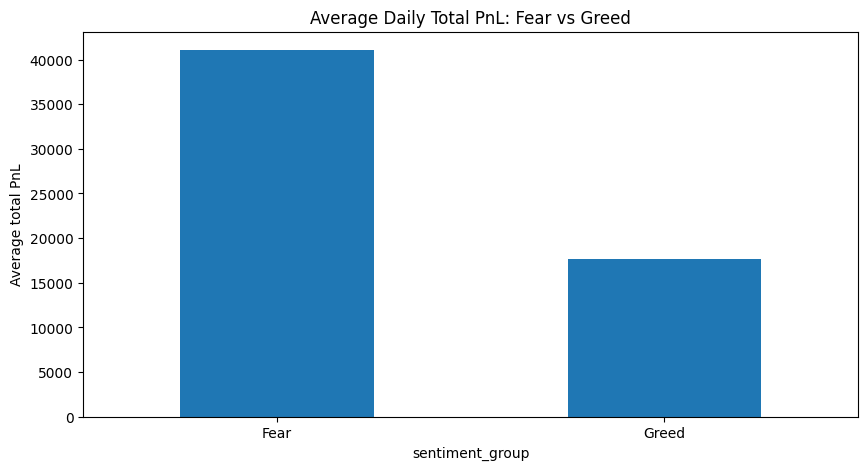

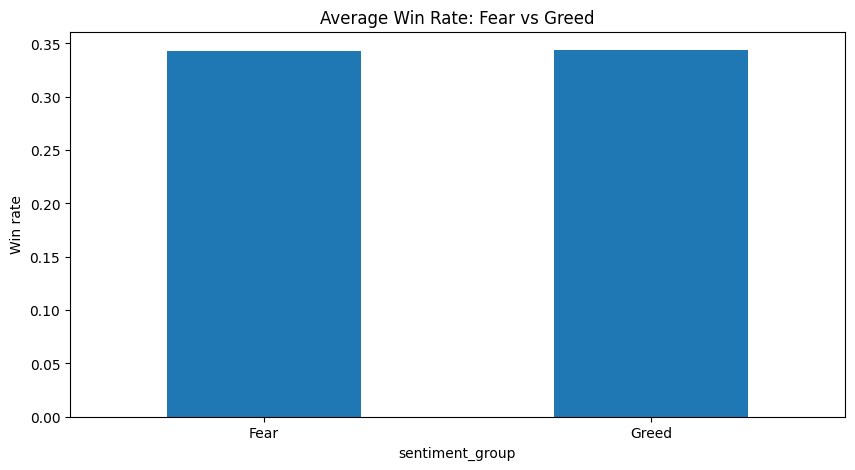

In [16]:
# Chart 1: Market-level performance on Fear vs Greed days
market_compare = (
    daily_market_fg.groupby('sentiment_group')
                   .agg(
                       avg_total_pnl=('total_pnl', 'mean'),
                       avg_win_rate=('win_rate', 'mean')
                   )
)

market_compare['avg_total_pnl'].plot(kind='bar', title='Average Daily Total PnL: Fear vs Greed')
plt.ylabel('Average total PnL')
plt.xticks(rotation=0)
plt.show()

market_compare['avg_win_rate'].plot(kind='bar', title='Average Win Rate: Fear vs Greed')
plt.ylabel('Win rate')
plt.xticks(rotation=0)
plt.show()


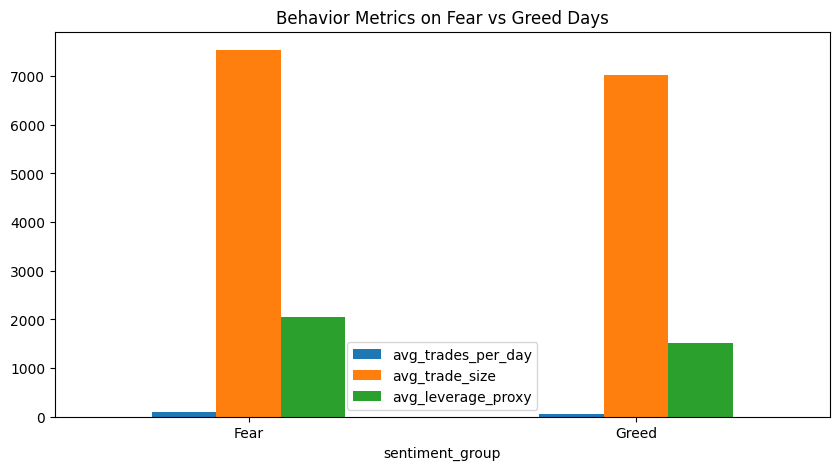

In [17]:
# Chart 2: Trader behavior by sentiment
behavior_compare[['avg_trades_per_day', 'avg_trade_size', 'avg_leverage_proxy']].plot(
    kind='bar',
    subplots=False,
    title='Behavior Metrics on Fear vs Greed Days'
)
plt.xticks(rotation=0)
plt.show()


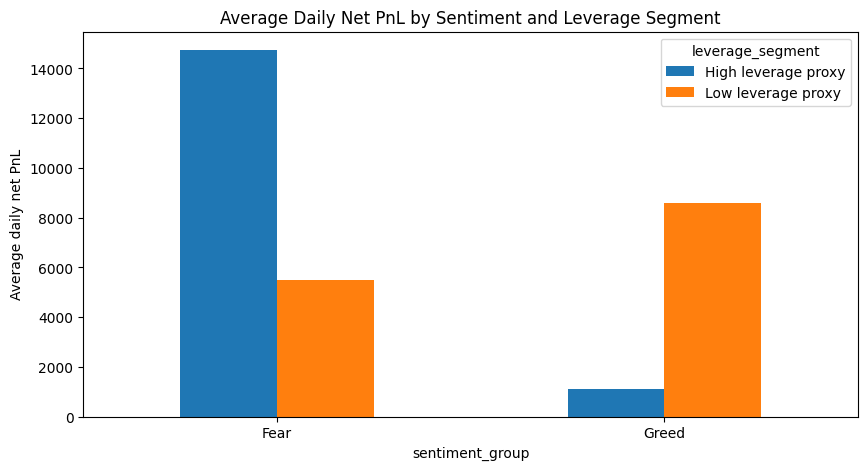

In [18]:
# Chart 3: Segment interaction with sentiment
pivot_seg = (
    fg_seg.groupby(['sentiment_group', 'leverage_segment'])['daily_net_pnl']
          .mean()
          .unstack()
)

pivot_seg.plot(kind='bar', title='Average Daily Net PnL by Sentiment and Leverage Segment')
plt.ylabel('Average daily net PnL')
plt.xticks(rotation=0)
plt.show()


## 13) Key findings summary

Use this section in your report / README.

### Example findings from this dataset
1. **Performance appears better on Fear days than Greed days.**  
   Market-level average daily total PnL is higher on Fear days than on Greed days, and trader-day average net PnL is also stronger on Fear days.

2. **Behavior changes with sentiment.**  
   On Greed days, traders appear to trade larger notional sizes and show a stronger long bias.  
   On Fear days, they appear to have lower average trade sizes but better realized PnL.

3. **Segment interaction matters.**  
   High leverage-proxy traders perform much better on Fear days than Greed days, while low leverage-proxy traders hold up better on Greed days.

4. **Frequent traders are not always better in Greed conditions.**  
   Frequent traders perform very strongly on Fear days, but their average daily PnL drops sharply on Greed days.

### Caution
- `leverage_proxy` is not true leverage because true account equity / leverage is unavailable.
- `drawdown_proxy` is based on cumulative daily net PnL in the observed sample only.


## 14) Strategy ideas / rules of thumb

### Rule 1
**During Greed days, cap leverage/exposure for high leverage-proxy traders.**  
Reason: high leverage-proxy accounts underperform materially on Greed days in this sample.

### Rule 2
**During Fear days, allow more activity for frequent traders, but keep position sizes disciplined.**  
Reason: frequent traders show stronger profitability on Fear days, suggesting that volatile risk-off conditions may reward active execution more than aggressive size expansion.

### Rule 3
**On Greed days, prefer selective long exposure instead of broad aggressive trading.**  
Reason: traders already lean more long on Greed days, but profitability does not increase proportionally.


## 15) Optional bonus: predictive model idea

A lightweight next-step extension:
- Build daily trader features:
  - previous-day PnL
  - win rate
  - trade count
  - avg trade size
  - leverage proxy
  - long share
  - sentiment value / Fear vs Greed class
- Target:
  - next-day profitability bucket (`loss`, `flat`, `profit`)
- Model:
  - Logistic Regression / Random Forest / XGBoost
- Evaluate:
  - accuracy, macro F1, confusion matrix
